In [ ]:
# Downloading
!pip install gensim scikit-learn==1.5.2
!pip install scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
# Buat scraping review
import requests
import pandas as pd
import time
from urllib.parse import quote

# Buat EDA
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Buat preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Buat text representation (TF-IDF & Word2Vec)

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

# Buat machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

# Buat deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Input

# Buat data balancing
from imblearn.over_sampling import RandomOverSampler

### Ambil data review game Uma Musume dari platform Steam

In [ ]:
def get_steam_review(appid, review_type="all", total_review=2000):
  reviews_list = []
  cursor = "*"

  while (len(reviews_list) < total_review):
    encoded_cursor = quote(cursor)
    url = (
            f'https://store.steampowered.com/appreviews/{appid}?json=1'
            f'&filter=recent'
            f'&language=english'
            f'&review_type={review_type}'
            f'&purchase_type=all'
            f'&num_per_page=100'
            f'&cursor={encoded_cursor}'
        )

    response = requests.get(url).json()

    if response.get('success') != 1:
      print(f"Terjadi kesalahan: {response}")
      break

    if not response.get('reviews'):
      print("Tidak ada review lagi yang ditemukan.")
      break

    for r in response['reviews']:
      reviews_list.append({
        'review': r['review'],
        'rating': r['voted_up'] # True = Positif, False = Negatif
      })

    cursor = response['cursor']

    print(f"Berhasil mengambil {len(reviews_list)} review.")

    time.sleep(2)


  pd.DataFrame(reviews_list[:total_review]).to_csv('game_reviews.csv', index=False)
  print("Review berhasil disimpan kedalam file 'game_reviews.csv'")

In [ ]:
appid = 3224770 # Uma Musume
get_steam_review(appid)

Berhasil mengambil 100 review.
Berhasil mengambil 200 review.
Berhasil mengambil 300 review.
Berhasil mengambil 399 review.
Berhasil mengambil 499 review.
Berhasil mengambil 599 review.
Berhasil mengambil 699 review.
Berhasil mengambil 799 review.
Berhasil mengambil 899 review.
Berhasil mengambil 999 review.
Berhasil mengambil 1099 review.
Berhasil mengambil 1199 review.
Berhasil mengambil 1299 review.
Berhasil mengambil 1399 review.
Berhasil mengambil 1499 review.
Berhasil mengambil 1599 review.
Berhasil mengambil 1699 review.
Berhasil mengambil 1799 review.
Berhasil mengambil 1899 review.
Berhasil mengambil 1999 review.
Berhasil mengambil 2099 review.
Review berhasil disimpan kedalam file 'game_reviews.csv'


### Data cleaning untuk ngilangin yang null

In [ ]:
df = pd.read_csv("game_reviews.csv")

print(df.info())
print(df['rating'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1997 non-null   object
 1   rating  2000 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 17.7+ KB
None
rating
True     1847
False     153
Name: count, dtype: int64


ada 6 data yang reviewnya null

In [ ]:
df = df.dropna(subset=['review'])

### EDA pada data

In [ ]:
def plot_cloud(text, title, color):
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

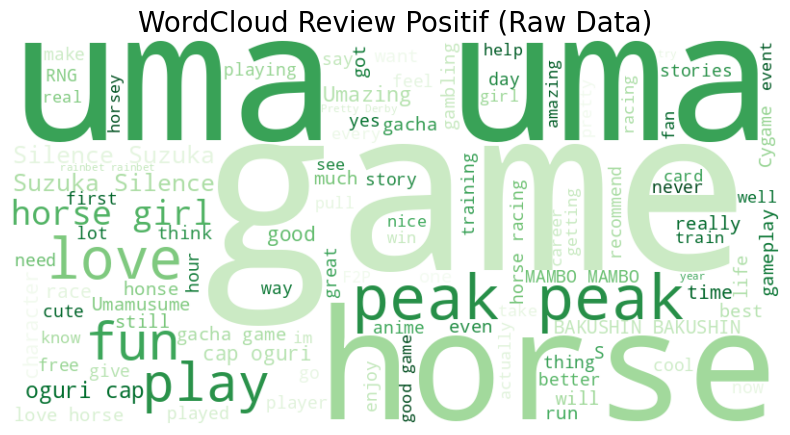

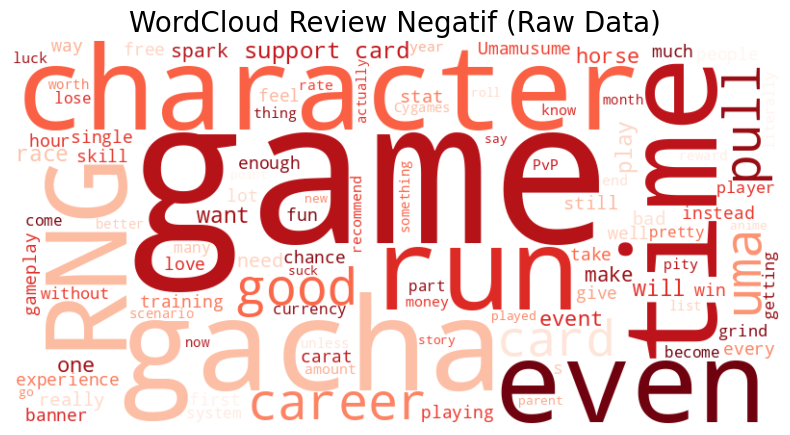

In [ ]:
pos_reviews = " ".join(df[df['rating'] == True]['review'].astype(str))
neg_reviews = " ".join(df[df['rating'] == False]['review'].astype(str))

plot_cloud(pos_reviews, "WordCloud Review Positif (Raw Data)", "Greens")
plot_cloud(neg_reviews, "WordCloud Review Negatif (Raw Data)", "Reds")

### Masih banyak stopwords & kata-kata yang bisa menjadi noise dll.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatize = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

excluded_negative_words = {"not", "no", "never", "neither", "nor"}
stop_words = stop_words - excluded_negative_words
additional_stopwords = {"game", "games", "play", "dota", "player", "get", "even", "make", "would", "time", "hour", "one", "still", "every", "fun",
 "people", "community", "better", "playing", "life", "im", "ive", "cant", "dont", "ur", "ye", "ok",
 "thats", "youre", "lol", "gg", "u"}
stop_words.update(additional_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def preprocess_data(text):
  text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())

  tokens = text.split()
  clean_tokens = [lemmatize.lemmatize(token.strip()) for token in tokens if token not in stop_words]

  return ' '.join(clean_tokens)

In [ ]:
pos_clean = preprocess_data(pos_reviews)
neg_clean = preprocess_data(neg_reviews)

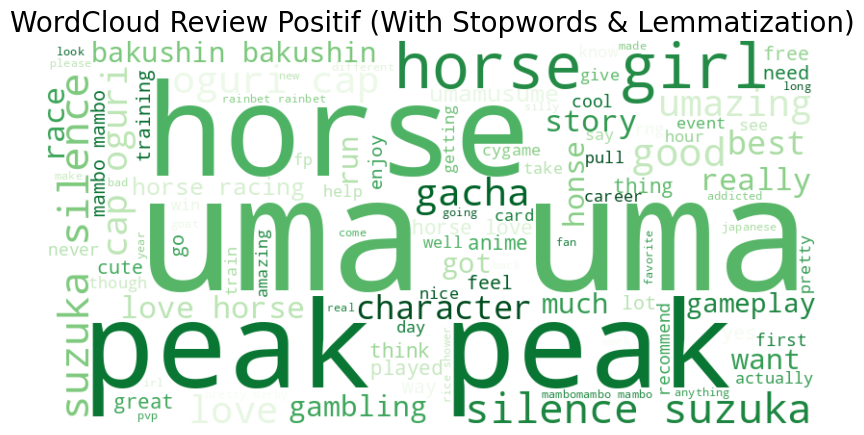

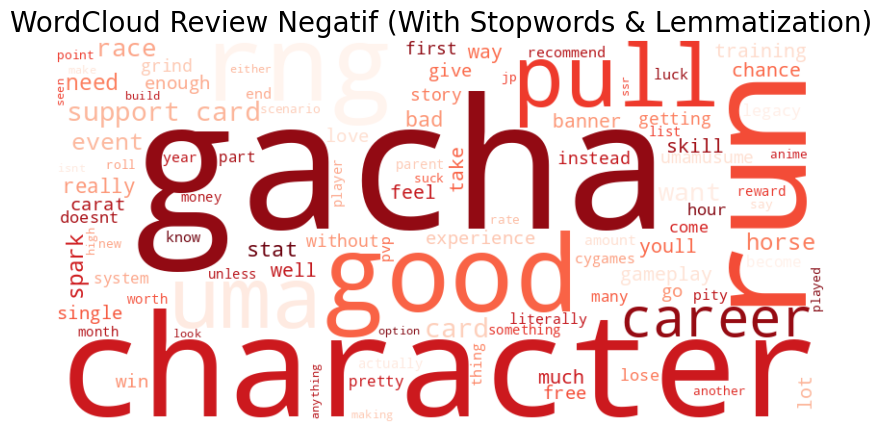

In [ ]:
plot_cloud(pos_clean, "WordCloud Review Positif (With Stopwords & Lemmatization)", "Greens")
plot_cloud(neg_clean, "WordCloud Review Negatif (With Stopwords & Lemmatization)", "Reds")

##Abis di preprocess, akan dilakukan text representation pakai metode TF-IDF & Word2Vec

In [ ]:
# apply preprocess ke dataframe
df['cleaned_review'] = df['review'].apply(preprocess_data)
df = df[df['cleaned_review'] != '']

In [ ]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review']).toarray()
print(f"Bentuk data TF-IDF: {X_tfidf.shape}")

Bentuk data TF-IDF: (1943, 2000)


In [ ]:
# Word2Vec
def get_average_word2vec(tokens, model, vector_size):
    vec = np.zeros(vector_size)
    count = 0
    for word in tokens:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

sentences = [review.split() for review in df['cleaned_review']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

X_w2v = np.array([get_average_word2vec(s, w2v_model, 100) for s in sentences])
print(f"Bentuk data Word2Vec: {X_w2v.shape}")

Bentuk data Word2Vec: (1943, 100)


## Lanjut ke splitting dataset & training, untuk training akan menggunakan model Logistic Regression & Random Forest

In [ ]:
y = df['rating'].astype(int) # True/False -> 1/0

# Split data TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Split data Word2Vec
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Logistic Regression
lr_pipeline = Pipeline([
    ('lr', LogisticRegression(max_iter=1000))
])

lr_params = {
    'lr__C': [0.1, 1, 10],
    'lr__solver': ['liblinear', 'lbfgs']
}

grid_lr_pipe = GridSearchCV(lr_pipeline, lr_params, cv=3, scoring='accuracy')
grid_lr_pipe.fit(X_train_tfidf, y_train)

print(f"Best Parameters LR (Pipeline): {grid_lr_pipe.best_params_}")
y_pred_lr = grid_lr_pipe.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))

Best Parameters LR (Pipeline): {'lr__C': 10, 'lr__solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.20      0.03      0.06        30
           1       0.92      0.99      0.96       359

    accuracy                           0.92       389
   macro avg       0.56      0.51      0.51       389
weighted avg       0.87      0.92      0.89       389



In [ ]:
# Random Forest
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

rf_params = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [None, 10, 20]
}

grid_rf_pipe = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring='accuracy')
grid_rf_pipe.fit(X_train_w2v, y_train)

print(f"Best Parameters RF (Pipeline): {grid_rf_pipe.best_params_}")
y_pred_rf = grid_rf_pipe.predict(X_test_w2v)
print(classification_report(y_test, y_pred_rf))

Best Parameters RF (Pipeline): {'rf__max_depth': None, 'rf__n_estimators': 50}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.92      0.99      0.95       359

    accuracy                           0.91       389
   macro avg       0.46      0.49      0.48       389
weighted avg       0.85      0.91      0.88       389



## Training dataset di deep learning buat perbandingan

In [ ]:
def create_model(neurons=64, optimizer='adam'):
    model = Sequential([
        Input(shape=(100,)), # Explicit input layer to remove warnings
        Dense(neurons, activation='relu'),
        Dropout(0.2),
        Dense(neurons // 2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
# ANN pake dataset Word2Vec
nn_model = KerasClassifier(model=create_model, verbose=0)

nn_params = {
    'model__neurons': [64, 128],
    'model__optimizer': ['adam', 'rmsprop'],
    'epochs': [10, 20, 30],
    'batch_size': [32]
}

grid_nn = GridSearchCV(estimator=nn_model, param_grid=nn_params, cv=3, scoring='accuracy')
grid_nn.fit(X_train_w2v, y_train)

print(f"Best Parameters Deep Learning: {grid_nn.best_params_}")
y_pred_nn = (grid_nn.predict(X_test_w2v) > 0.5).astype(int)
print(classification_report(y_test, y_pred_nn))

Best Parameters Deep Learning: {'batch_size': 32, 'epochs': 10, 'model__neurons': 64, 'model__optimizer': 'adam'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.92      1.00      0.96       359

    accuracy                           0.92       389
   macro avg       0.46      0.50      0.48       389
weighted avg       0.85      0.92      0.89       389



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dari ketiga model yang telah dilakukan training, didapatkan bahwa model Logistic Regression memiliki hasil yang terbaik dengan akurasi 80%. Namun, ketiga model memiliki skor yang jelek pada review negatif, kemungkinan karena data imbalance pada dataset.

## Bikin seluruh process nya jadi 1 function untuk memudahkan hidup

In [ ]:
def run_full_evaluation(input_df):
    y = input_df['rating'].astype(int)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=2000)
    X_tfidf = tfidf.fit_transform(input_df['cleaned_review']).toarray()

    # Word2Vec
    sentences = [review.split() for review in input_df['cleaned_review']]
    w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
    X_w2v = np.array([get_average_word2vec(s, w2v, 100) for s in sentences])

    # Split
    X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
    X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

    # Logistic Regression (TF-IDF)
    grid_lr = GridSearchCV(lr_pipeline, lr_params, cv=3, scoring='accuracy', verbose=0)
    grid_lr.fit(X_train_tfidf, y_train)
    print("\n[1] Logistic Regression (TF-IDF) Results:")
    print(classification_report(y_test, grid_lr.predict(X_test_tfidf)))

    # Random Forest (Word2Vec)
    grid_rf = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring='accuracy', verbose=0)
    grid_rf.fit(X_train_w2v, y_train)
    print("\n[2] Random Forest (Word2Vec) Results:")
    print(classification_report(y_test, grid_rf.predict(X_test_w2v)))

    # ANN (Word2Vec)
    grid_nn = GridSearchCV(estimator=nn_model, param_grid=nn_params, cv=3, scoring='accuracy', verbose=0)
    grid_nn.fit(X_train_w2v, y_train)
    print("\n[3] Deep Learning (Word2Vec) Results:")
    y_pred_nn = (grid_nn.predict(X_test_w2v) > 0.5).astype(int)
    print(classification_report(y_test, y_pred_nn))

    return {"lr": grid_lr, "rf": grid_rf, "nn": grid_nn}

In [ ]:
# Tes functionnya di data sebelum balancing
baseline_results = run_full_evaluation(df)


[1] Logistic Regression (TF-IDF) Results:
              precision    recall  f1-score   support

           0       0.20      0.03      0.06        30
           1       0.92      0.99      0.96       359

    accuracy                           0.92       389
   macro avg       0.56      0.51      0.51       389
weighted avg       0.87      0.92      0.89       389


[2] Random Forest (Word2Vec) Results:
              precision    recall  f1-score   support

           0       0.25      0.03      0.06        30
           1       0.92      0.99      0.96       359

    accuracy                           0.92       389
   macro avg       0.59      0.51      0.51       389
weighted avg       0.87      0.92      0.89       389


[3] Deep Learning (Word2Vec) Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.92      1.00      0.96       359

    accuracy                           0.92       389
   macr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Handle Data Imbalance

In [ ]:
X = df[['cleaned_review']]
y = df['rating'].astype(int)

ros = RandomOverSampler(random_state=42)
X_resampled_raw, y_resampled = ros.fit_resample(X, y)

df_balanced = pd.DataFrame({
    'cleaned_review': X_resampled_raw['cleaned_review'],
    'rating': y_resampled
})

print("Original class distribution:\n", y.value_counts())
print("\nBalanced class distribution:\n", y_resampled.value_counts())

Original class distribution:
 rating
1    1795
0     148
Name: count, dtype: int64

Balanced class distribution:
 rating
1    1795
0    1795
Name: count, dtype: int64


In [ ]:
balanced_results = run_full_evaluation(df_balanced)


[1] Logistic Regression (TF-IDF) Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       359
           1       0.99      0.96      0.98       359

    accuracy                           0.98       718
   macro avg       0.98      0.98      0.98       718
weighted avg       0.98      0.98      0.98       718


[2] Random Forest (Word2Vec) Results:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       359
           1       1.00      0.97      0.99       359

    accuracy                           0.99       718
   macro avg       0.99      0.99      0.99       718
weighted avg       0.99      0.99      0.99       718


[3] Deep Learning (Word2Vec) Results:
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       359
           1       0.95      0.72      0.82       359

    accuracy                           0.84       718
   macr